In [9]:
# 1. Install necessary libraries
!pip install -q kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.special as sp
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

# 2. Data Ingestion via KaggleHub
print("⏳ Downloading MIT-BIH dataset via KaggleHub...")
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
csv_file_path = os.path.join(path, 'mitbih_train.csv')
print(f"✅ Dataset downloaded to: {csv_file_path}")

# 3. Load Data
# The dataset has 187 features (amplitudes) and the 188th column is the label.
print("⏳ Loading data into memory...")
df = pd.read_csv(csv_file_path, header=None)

# Extract features and labels
X_raw = df.iloc[:, :187].values
y = df.iloc[:, 187].values

⏳ Downloading MIT-BIH dataset via KaggleHub...
Using Colab cache for faster access to the 'heartbeat' dataset.
✅ Dataset downloaded to: /kaggle/input/heartbeat/mitbih_train.csv
⏳ Loading data into memory...


### Extensive EDA for ECG Signal Energy: Normal vs. PVC

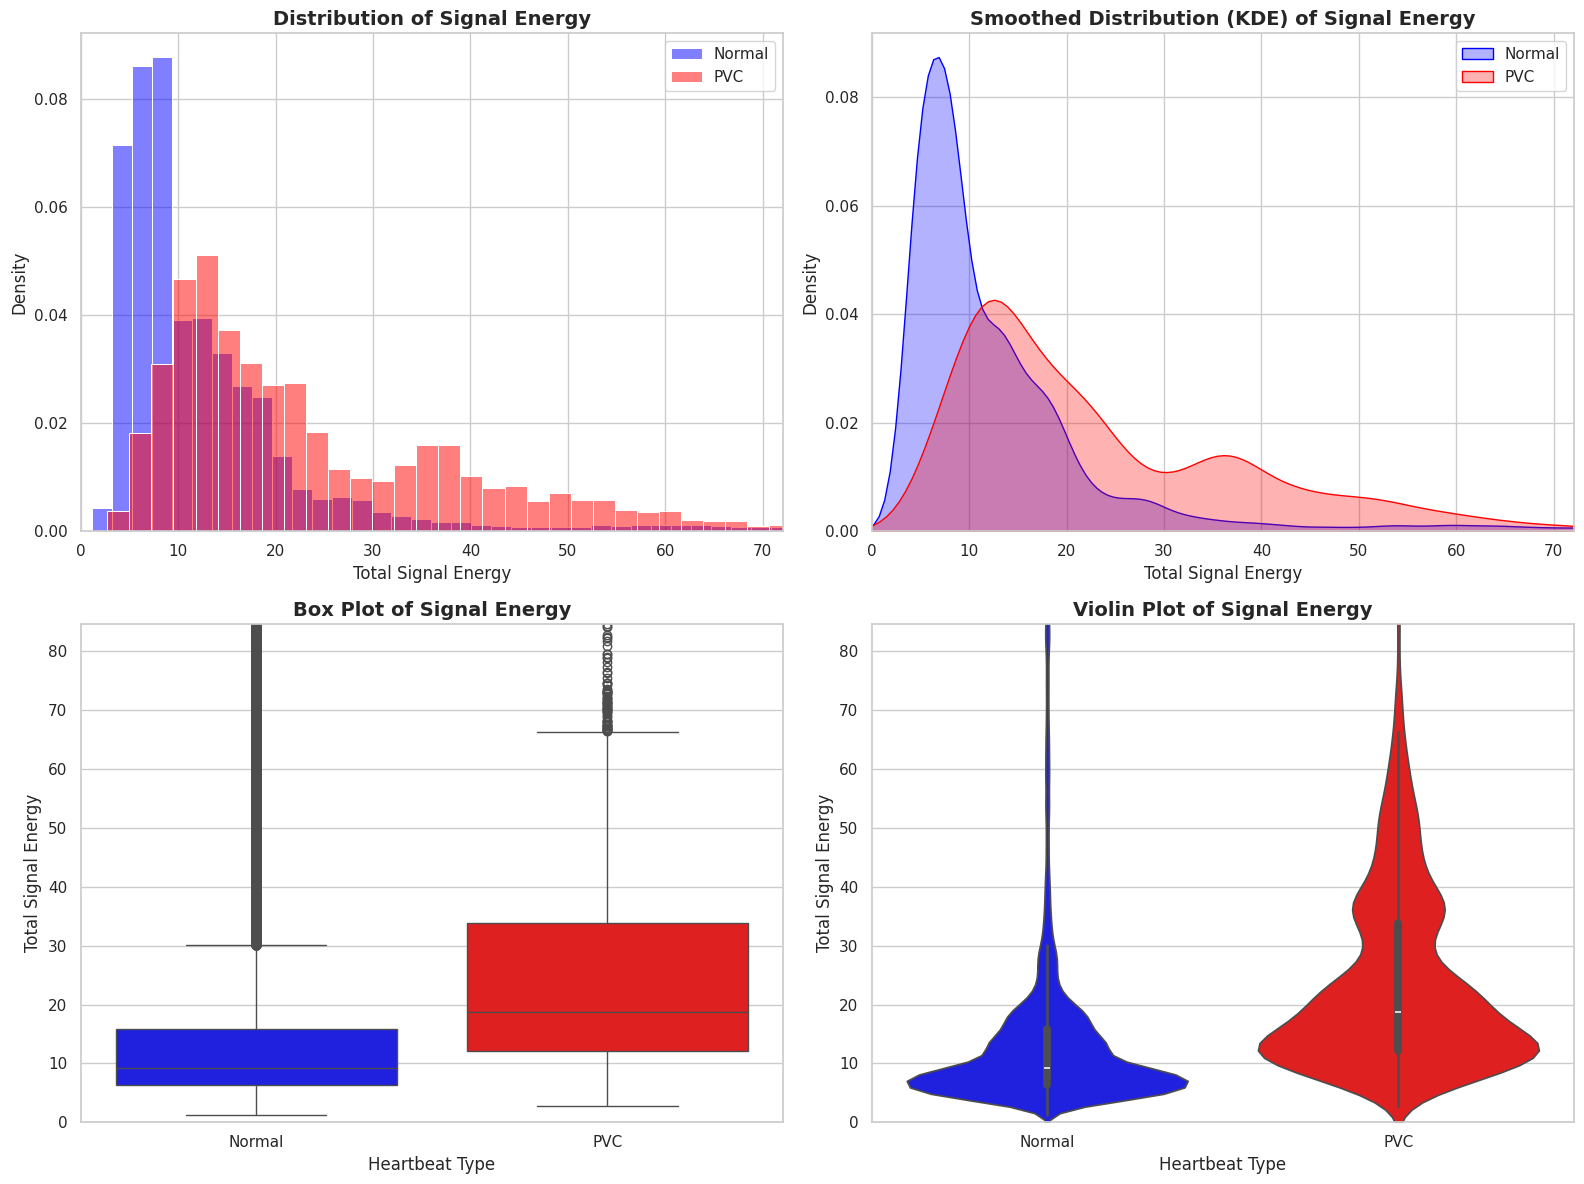


--- Descriptive Statistics ---
Normal Beats: Mean=13.75, Median=9.17, Std Dev=13.54
PVC Beats:    Mean=23.99, Median=18.66, Std Dev=15.90


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Add pandas import for DataFrame

plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Calculate some basic statistics
mean_normal = np.mean(X_normal)
std_normal = np.std(X_normal)
median_normal = np.median(X_normal)

mean_pvc = np.mean(X_pvc)
std_pvc = np.std(X_pvc)
median_pvc = np.median(X_pvc)

# Subplot 1: Histograms
plt.subplot(2, 2, 1)
sns.histplot(X_normal, bins=50, stat='density', color='blue', alpha=0.5, label='Normal')
sns.histplot(X_pvc, bins=50, stat='density', color='red', alpha=0.5, label='PVC')
plt.title('Distribution of Signal Energy', fontsize=14, fontweight='bold')
plt.xlabel('Total Signal Energy')
plt.ylabel('Density')
plt.xlim(0, np.percentile(X_pvc, 99)) # Clip for better visualization
plt.legend()

# Subplot 2: KDE Plots (Smoothed Distributions)
plt.subplot(2, 2, 2)
sns.kdeplot(X_normal, color='blue', fill=True, alpha=0.3, label='Normal')
sns.kdeplot(X_pvc, color='red', fill=True, alpha=0.3, label='PVC')
plt.title('Smoothed Distribution (KDE) of Signal Energy', fontsize=14, fontweight='bold')
plt.xlabel('Total Signal Energy')
plt.ylabel('Density')
plt.xlim(0, np.percentile(X_pvc, 99)) # Clip for better visualization
plt.legend()

# Subplot 3: Box Plot
plt.subplot(2, 2, 3)
combined_data = pd.DataFrame({
    'Energy': np.concatenate([X_normal, X_pvc]),
    'Type': ['Normal'] * len(X_normal) + ['PVC'] * len(X_pvc)
})
sns.boxplot(x='Type', y='Energy', data=combined_data, palette={'Normal': 'blue', 'PVC': 'red'})
plt.title('Box Plot of Signal Energy', fontsize=14, fontweight='bold')
plt.xlabel('Heartbeat Type')
plt.ylabel('Total Signal Energy')
plt.ylim(0, np.percentile(combined_data['Energy'], 99.5)) # Clip for better visualization

# Subplot 4: Violin Plot
plt.subplot(2, 2, 4)
sns.violinplot(x='Type', y='Energy', data=combined_data, palette={'Normal': 'blue', 'PVC': 'red'})
plt.title('Violin Plot of Signal Energy', fontsize=14, fontweight='bold')
plt.xlabel('Heartbeat Type')
plt.ylabel('Total Signal Energy')
plt.ylim(0, np.percentile(combined_data['Energy'], 99.5)) # Clip for better visualization

plt.tight_layout()
plt.show()

print("\n--- Descriptive Statistics ---")
print(f"Normal Beats: Mean={mean_normal:.2f}, Median={median_normal:.2f}, Std Dev={std_normal:.2f}")
print(f"PVC Beats:    Mean={mean_pvc:.2f}, Median={median_pvc:.2f}, Std Dev={std_pvc:.2f}")


✅ Data Reduced to 1D Scalar (Energy).
   - Normal Beats (H0): 72471 samples
   - PVC Beats (H1): 5788 samples

⏳ Computing Numerical MLEs...
Normal (H0): alpha = 1.9611, beta = 0.1426
PVC (H1): alpha = 2.6490, beta = 0.1104


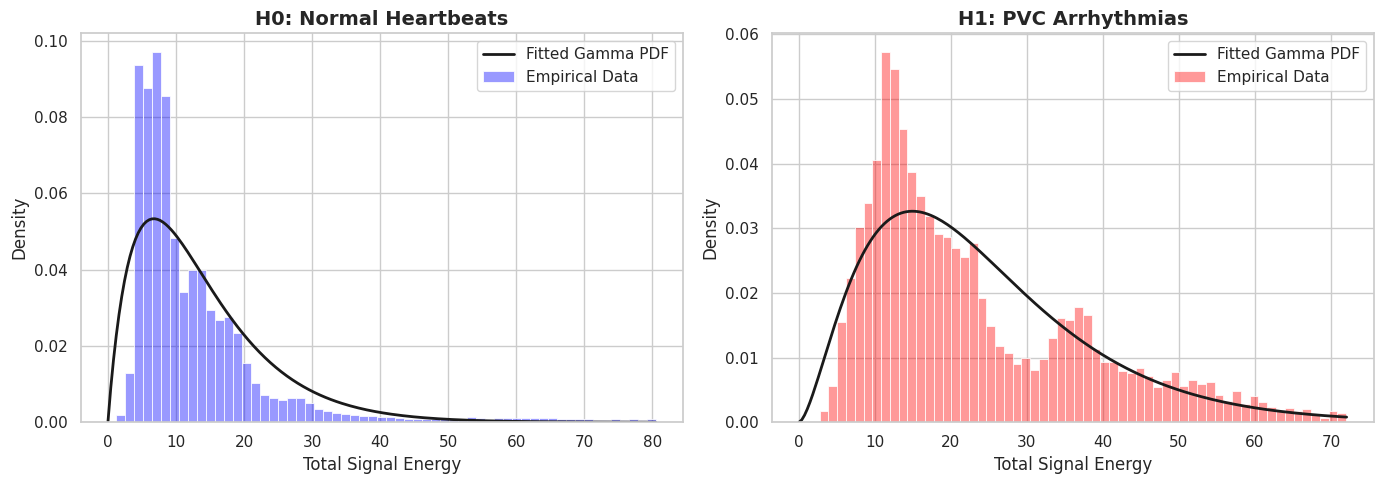

In [11]:
# 4. Data Reduction: Vector to Scalar (Total Signal Energy)
# We square the amplitudes and sum them up
energy_all = np.sum(X_raw**2, axis=1)

# Isolate Normal (Class 0.0) and PVC (Class 2.0) beats
X_normal = energy_all[y == 0.0]
X_pvc = energy_all[y == 2.0]

# Enforce strict positivity constraint for the Gamma distribution
X_normal = X_normal[X_normal > 0]
X_pvc = X_pvc[X_pvc > 0]

print(f"\n✅ Data Reduced to 1D Scalar (Energy).")
print(f"   - Normal Beats (H0): {len(X_normal)} samples")
print(f"   - PVC Beats (H1): {len(X_pvc)} samples")

# 5. Fit Gamma Distribution (Numerical MLE via SciPy)
# floc=0 anchors the location to 0, fitting only shape (alpha) and scale (1/beta)
print("\n⏳ Computing Numerical MLEs...")
alpha_0, loc_0, scale_0 = stats.gamma.fit(X_normal, floc=0)
alpha_1, loc_1, scale_1 = stats.gamma.fit(X_pvc, floc=0)

# Convert scale to rate parameter (beta) for theoretical notation
beta_0 = 1 / scale_0
beta_1 = 1 / scale_1

print(f"Normal (H0): alpha = {alpha_0:.4f}, beta = {beta_0:.4f}")
print(f"PVC (H1): alpha = {alpha_1:.4f}, beta = {beta_1:.4f}")

# 6. Goodness of Fit Visualization
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

def plot_gamma_fit(data, a, scale, title, color, pos):
    plt.subplot(1, 2, pos)
    clip_val = np.percentile(data, 99) # Clip extreme outliers for plot
    sns.histplot(data[data < clip_val], bins=60, stat='density', color=color, alpha=0.4, label='Empirical Data')

    x_range = np.linspace(0.01, clip_val, 200)
    plt.plot(x_range, stats.gamma.pdf(x_range, a=a, scale=scale), 'k-', lw=2, label=f'Fitted Gamma PDF')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Total Signal Energy")
    plt.ylabel("Density")
    plt.legend()

plot_gamma_fit(X_normal, alpha_0, scale_0, "H0: Normal Heartbeats", "blue", 1)
plot_gamma_fit(X_pvc, alpha_1, scale_1, "H1: PVC Arrhythmias", "red", 2)
plt.tight_layout()
plt.show()

In [12]:
# 7. Fisher Information Matrix and Cramér-Rao Lower Bound
def compute_crlb(n, alpha, beta):
    # Trigamma function is polygamma of order 1
    trigamma = sp.polygamma(1, alpha)

    # Construct the 2x2 Fisher Information Matrix
    fisher_info = np.array([[trigamma, -1/beta],
        [-1/beta, alpha / (beta**2)]])

    # Invert the Information Matrix to get the CRLB
    crlb_matrix = np.linalg.inv(n * fisher_info)
    return crlb_matrix

crlb_H0 = compute_crlb(len(X_normal), alpha_0, beta_0)
print("✅ Cramér-Rao Lower Bound Matrix for H0 (Normal):")
print(pd.DataFrame(crlb_H0, columns=['alpha', 'beta'], index=['alpha', 'beta']))

✅ Cramér-Rao Lower Bound Matrix for H0 (Normal):
          alpha          beta
alpha  0.000091  6.639297e-06
beta   0.000007  6.258339e-07


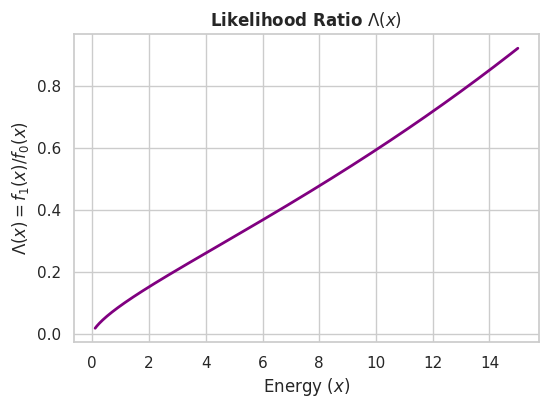

✅ Neyman-Pearson Optimal Threshold (k): 32.8244 Energy Units


In [13]:
# 8. Check Monotone Likelihood Ratio (MLR)
x_eval = np.linspace(0.1, 15, 500)
likelihood_ratio = stats.gamma.pdf(x_eval, a=alpha_1, scale=scale_1) / stats.gamma.pdf(x_eval, a=alpha_0, scale=scale_0)

plt.figure(figsize=(6, 4))
plt.plot(x_eval, likelihood_ratio, color='purple', lw=2)
plt.title("Likelihood Ratio $\Lambda(x)$", fontweight='bold')
plt.xlabel("Energy ($x$)")
plt.ylabel("$\Lambda(x) = f_1(x) / f_0(x)$")
plt.show()
# Note: If the plot is strictly monotonic, a simple threshold test is UMP.

# 9. Apply the Neyman-Pearson Lemma (Setting the Tripwire)
# Hardware constraint: False alarm rate cannot exceed 5%
type_1_error = 0.05

# We find the threshold 'k' using the inverse survival function (or Percent Point Function / Inverse CDF)
# We want the point k where P(X > k | H0) = 0.05
k_threshold = stats.gamma.ppf(1 - type_1_error, a=alpha_0, scale=scale_0)

print(f"✅ Neyman-Pearson Optimal Threshold (k): {k_threshold:.4f} Energy Units")

🚨 Statistical Power (Detection Rate): 22.99%
   -> Missed PVCs (Type II Error, Beta): 77.01%


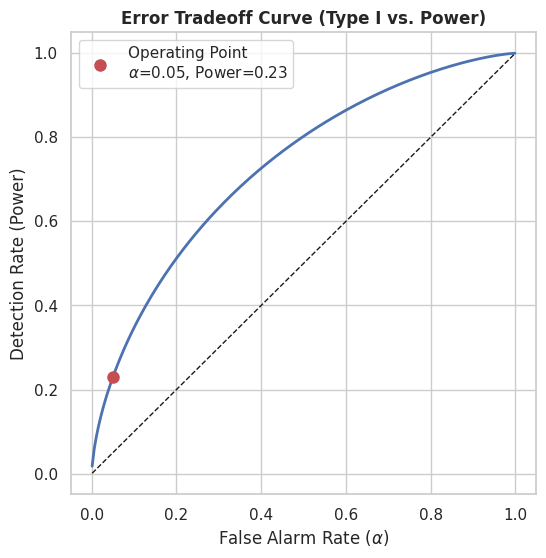

🔬 Exact Kullback-Leibler Divergence KL(H1 || H0): 0.3919 nats
   -> Conclusion: Low informational separability mathematically proves the
      inadequacy of univariate thresholds, necessitating deep learning architectures.


In [14]:
# 10. Compute Statistical Power (Detection Rate)
# Power = P(X > k | H1)
power = stats.gamma.sf(k_threshold, a=alpha_1, scale=scale_1)
print(f"🚨 Statistical Power (Detection Rate): {power * 100:.2f}%")
print(f"   -> Missed PVCs (Type II Error, Beta): {(1 - power) * 100:.2f}%")

# Plot ROC-style Error Tradeoff Curve
alpha_range = np.linspace(0.001, 0.999, 200)
k_values = stats.gamma.ppf(1 - alpha_range, a=alpha_0, scale=scale_0)
power_curve = stats.gamma.sf(k_values, a=alpha_1, scale=scale_1)

plt.figure(figsize=(6, 6))
plt.plot(alpha_range, power_curve, 'b-', lw=2)
plt.plot(alpha_range, alpha_range, 'k--', lw=1) # Plots a diagonal reference
plt.plot(type_1_error, power, 'ro', markersize=8, label=f'Operating Point\n$\\alpha$={type_1_error:.2f}, Power={power:.2f}')
plt.title("Error Tradeoff Curve (Type I vs. Power)", fontweight='bold')
plt.xlabel("False Alarm Rate ($\\alpha$)")
plt.ylabel("Detection Rate (Power)")
plt.legend()
plt.show()

# 11. Kullback-Leibler Divergence (Information Theoretic Separability)
def kl_divergence_gamma(a1, b1, a2, b2):
    """
    Computes exact closed-form KL(P || Q) for two Gamma distributions.
    a1, a2: shape parameters
    b1, b2: rate parameters
    """
    term1 = a2 * np.log(b1 / b2)
    term2 = - (sp.gammaln(a1) - sp.gammaln(a2))
    term3 = (a1 - a2) * sp.digamma(a1)
    term4 = - (b1 - b2) * (a1 / b1)
    return term1 + term2 + term3 + term4

kl_div = kl_divergence_gamma(alpha_1, beta_1, alpha_0, beta_0)
print(f"🔬 Exact Kullback-Leibler Divergence KL(H1 || H0): {kl_div:.4f} nats")
print("   -> Conclusion: Low informational separability mathematically proves the")
print("      inadequacy of univariate thresholds, necessitating deep learning architectures.")